In [1]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
df=load_iris()
print(dir(df))

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']


In [2]:
df.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [3]:
df.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [4]:
df.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [5]:
df.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [6]:
final=pd.DataFrame(df.data,columns=df.feature_names)
final

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [7]:
final["new_target"]=df.target
final

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),new_target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [8]:
print(len(final))

150


In [9]:
cond1=final["new_target"]==0
final[cond1].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),new_target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
cond2=final["new_target"]==1
final[cond2].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),new_target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1


In [11]:
cond3=final["new_target"]==2
final[cond3].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),new_target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2


In [12]:
x=df.data
y=df.target

In [13]:
model=KNeighborsClassifier()
result=cross_val_score(model,x,y,cv=5).mean()
result

np.float64(0.9733333333333334)

In [14]:
model.fit(x,y)
print(model.predict([[6.5,3.0,5.8,2.2]]))


[2]


In [15]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
df=pd.read_csv("income.csv")
df

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


In [16]:
model=KMeans(n_clusters=3)
y_prediction=model.fit_predict(df[["Age","Income($)"]])
y_prediction

array([0, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2],
      dtype=int32)

In [17]:
df["cluster"]=y_prediction
df

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,0
2,Mohan,29,61000,2
3,Ismail,28,60000,2
4,Kory,42,150000,1
5,Gautam,39,155000,1
6,David,41,160000,1
7,Andrea,38,162000,1
8,Brad,36,156000,1
9,Angelina,35,130000,1


In [18]:
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]

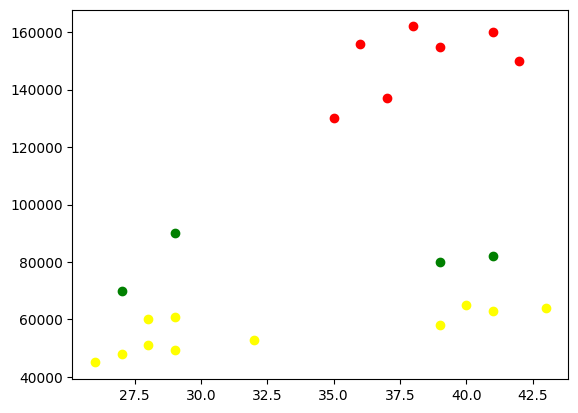

In [19]:
plt.scatter(df1["Age"],df1["Income($)"],color="green")
plt.scatter(df2["Age"],df2["Income($)"],color="red")
plt.scatter(df3["Age"],df3["Income($)"],color="yellow")

In [20]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
df=pd.read_csv("income.csv")
df

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


In [21]:
obj=MinMaxScaler(feature_range=(0,1))
df[["Age","Income($)"]]=obj.fit_transform(df[["Age","Income($)"]])
df

,Name,Age,Income($)
0,Rob,0.058824,0.213675
1,Michael,0.176471,0.384615
2,Mohan,0.176471,0.136752
3,Ismail,0.117647,0.128205
4,Kory,0.941176,0.897436
5,Gautam,0.764706,0.940171
6,David,0.882353,0.982906
7,Andrea,0.705882,1.000000
8,Brad,0.588235,0.948718
9,Angelina,0.529412,0.726496


In [22]:
model=KMeans(n_clusters=3)
y_prediction=model.fit_predict(df[["Age","Income($)"]])
y_prediction

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [23]:
df["cluster"]=y_prediction
df

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0
5,Gautam,0.764706,0.940171,0
6,David,0.882353,0.982906,0
7,Andrea,0.705882,1.000000,0
8,Brad,0.588235,0.948718,0
9,Angelina,0.529412,0.726496,0


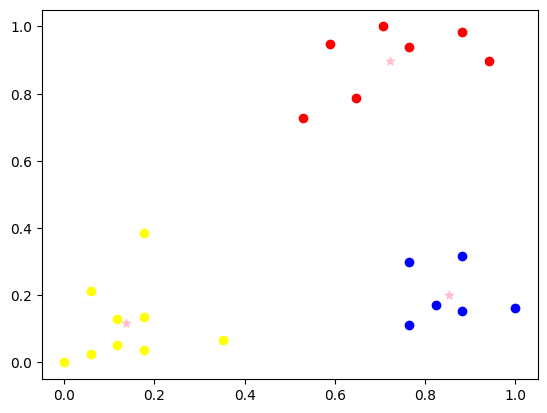

In [24]:
df1=df[df.cluster==0]
df2=df[df.cluster==1]
df3=df[df.cluster==2]
plt.scatter(df1["Age"],df1["Income($)"],color="red")
plt.scatter(df2["Age"],df2["Income($)"],color="yellow")
plt.scatter(df3["Age"],df3["Income($)"],color="blue")
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],label="centroid",color="pink",marker="*")

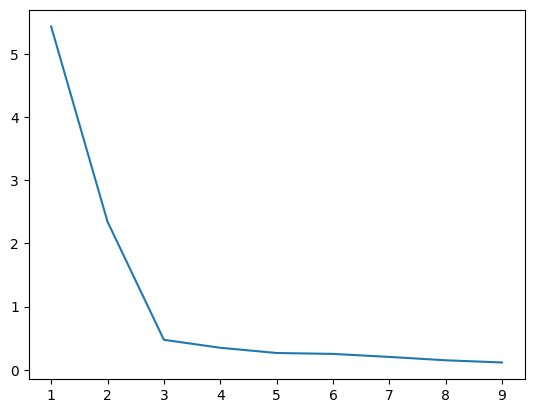

In [25]:
mse=[]
krange=range(1,10)
for k in krange:
    model=KMeans(n_clusters=k)
    model.fit(df[["Age","Income($)"]])
    mse.append(model.inertia_)
plt.plot(krange,mse)

In [26]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
df=load_iris()
print(dir(df))

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']


In [27]:
x=df.data
y=df.target

In [28]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=0)
model=SVC(kernel="poly",C=30,gamma="auto")
model.fit(X_train,Y_train)
print(model.score(X_test,Y_test))

1.0


In [29]:
x=df.data
y=df.target

In [30]:
model=SVC(kernel="poly",C=10,gamma="auto")
result=cross_val_score(model,x,y,cv=5)
result

array([1.        , 1.        , 0.9       , 0.93333333, 1.        ])

In [31]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_iris
from sklearn.svm import SVC
df=load_iris()
print(dir(df))


['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']


In [32]:
x=df.data
y=df.target

In [49]:
d={ "C":[1,10,20],
    "kernel":["rbf","linear"]
  }

In [50]:
model=SVC()
obj=GridSearchCV(model,d,cv=3,return_train_score=False)
obj.fit(x,y)
print(obj.cv_results_)
df=pd.DataFrame(obj.cv_results_)
df

{'mean_fit_time': array([0.00131814, 0.00087007, 0.00184973, 0.00150347, 0.00216889,
       0.00150633]), 'std_fit_time': array([0.00064901, 0.00041685, 0.00042981, 0.0004703 , 0.00049273,
       0.00065946]), 'mean_score_time': array([0.00095193, 0.00062919, 0.00144394, 0.00169126, 0.00180316,
       0.00078026]), 'std_score_time': array([0.00024598, 0.00030515, 0.00047119, 0.00028013, 0.00030126,
       0.00026229]), 'param_C': masked_array(data=[1, 1, 10, 10, 20, 20],
             mask=[False, False, False, False, False, False],
       fill_value=999999), 'param_kernel': masked_array(data=['rbf', 'linear', 'rbf', 'linear', 'rbf', 'linear'],
             mask=[False, False, False, False, False, False],
       fill_value=np.str_('?'),
            dtype=object), 'params': [{'C': 1, 'kernel': 'rbf'}, {'C': 1, 'kernel': 'linear'}, {'C': 10, 'kernel': 'rbf'}, {'C': 10, 'kernel': 'linear'}, {'C': 20, 'kernel': 'rbf'}, {'C': 20, 'kernel': 'linear'}], 'split0_test_score': array([0.96, 1.  , 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001318,0.000649,0.000952,0.000246,1,rbf,"{'C': 1, 'kernel': 'rbf'}",0.96,0.98,0.94,0.960000,0.016330,6
1,0.000870,0.000417,0.000629,0.000305,1,linear,"{'C': 1, 'kernel': 'linear'}",1.00,1.00,0.98,0.993333,0.009428,1
2,0.001850,0.000430,0.001444,0.000471,10,rbf,"{'C': 10, 'kernel': 'rbf'}",0.98,1.00,0.94,0.973333,0.024944,3
3,0.001503,0.000470,0.001691,0.000280,10,linear,"{'C': 10, 'kernel': 'linear'}",1.00,0.94,0.98,0.973333,0.024944,3
4,0.002169,0.000493,0.001803,0.000301,20,rbf,"{'C': 20, 'kernel': 'rbf'}",0.98,0.98,0.98,0.980000,0.000000,2
5,0.001506,0.000659,0.000780,0.000262,20,linear,"{'C': 20, 'kernel': 'linear'}",1.00,0.94,0.96,0.966667,0.024944,5


In [51]:
df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_C', 'param_kernel', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')

In [52]:
cols=["param_C","param_kernel","mean_test_score"]
df=df[cols]
df

,param_C,param_kernel,mean_test_score
0,1,rbf,0.960000
1,1,linear,0.993333
2,10,rbf,0.973333
3,10,linear,0.973333
4,20,rbf,0.980000
5,20,linear,0.966667


In [54]:
print(obj.best_params_)

{'C': 1, 'kernel': 'linear'}


In [55]:
print(obj.best_score_)

0.9933333333333333


In [58]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
df=load_iris()
print(dir(df))

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']


In [59]:
x=df.data
y=df.target

In [60]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [62]:
model=KNeighborsClassifier(n_neighbors=4)
model.fit(X_train,Y_train)
print(model.predict(X_test))

[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]
